# Ovarian Cancer Somatic Mutations — ML Benchmark

**Author:** Mai Nguyen  
**Dataset:** [electricsheepafrica/ovarian-somatic-mutations](https://huggingface.co/datasets/electricsheepafrica/ovarian-somatic-mutations)  
**Goal:** Benchmark multiple ML models to predict clinical outcomes from somatic mutation profiles

## Clinical Motivation
Ovarian cancer is the most lethal gynaecological malignancy. Predicting **platinum chemotherapy response** (Sensitive vs Resistant) from genomic profiles at diagnosis could directly inform treatment decisions — reducing unnecessary toxicity and improving outcomes. This notebook aims to develop ML models on a ovarian cancer cohort based on clinical + omics data. The dataset obtained from `HuggingFace` is from African patients.

## Analysis Overview
1. Load data via HuggingFace API
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. ML benchmark: Logistic Regression → Random Forest → XGBoost → LightGBM → MLP
5. Feature importance & biological interpretation
6. Clinical insights

## 0. Setup & Installation

In [1]:
# Install required packages (run once in Colab/Kaggle)
!pip install datasets huggingface_hub scikit-learn xgboost lightgbm shap matplotlib seaborn pandas numpy -q

## 1. Connect to HuggingFace & Load Data

### How HuggingFace API works
HuggingFace provides the `datasets` library to load any public dataset directly — **no manual download needed**.

For **public datasets** (like this one): no API key required.  
For **private/gated datasets**: you need a HuggingFace token.

```
# Get your token (for private datasets):
# 1. Go to https://huggingface.co/settings/tokens
# 2. Create a new token (read access is enough)
# 3. Use huggingface_hub.login(token='hf_yourtoken')
```

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np

# ── For PRIVATE or GATED datasets, login first ──────────────────
# from huggingface_hub import login
# login(token='hf_your_token_here')   # or set env var HF_TOKEN

# ── Load public dataset directly — no download needed ───────────
print('Loading dataset from HuggingFace...')
dataset = load_dataset('electricsheepafrica/ovarian-somatic-mutations')
print(f'Dataset loaded: {dataset}')

# Convert to pandas DataFrame
df = dataset['train'].to_pandas()
print(f'\nShape: {df.shape}')
df.head()

/Users/nguyenma/miniconda3/envs/cancer-dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset from HuggingFace...


Dataset loaded: DatasetDict({
    train: Dataset({
        features: ['sample_id', 'region', 'age', 'age_group', 'histologic_subtype', 'stage', 'grade', 'platinum_response', 'msi_status', 'msi_score', 'tmb_mut_per_mb', 'TP53_mut', 'BRCA1_mut', 'BRCA2_mut', 'NF1_mut', 'RB1_mut', 'PTEN_mut', 'PIK3CA_mut', 'KRAS_mut', 'ARID1A_mut', 'CTNNB1_mut', 'CDK12_mut', 'ATM_mut', 'ATR_mut', 'cnv_burden_fraction_genome_altered', 'aneuploidy_score', 'n_focal_amplifications', 'n_focal_deletions', 'hrd_score', 'CCNE1_amp', 'MYC_amp', 'ERBB2_amp', 'PTEN_del', 'RB1_del', 'NF1_del'],
        num_rows: 30000
    })
})

Shape: (30000, 35)


,sample_id,region,age,age_group,histologic_subtype,stage,grade,platinum_response,msi_status,msi_score,...,aneuploidy_score,n_focal_amplifications,n_focal_deletions,hrd_score,CCNE1_amp,MYC_amp,ERBB2_amp,PTEN_del,RB1_del,NF1_del
0,OV_SAMPLE_00000,Southern_Africa,60.0,50-64,High_grade_serous,IV,3,Sensitive,MSS,0.119812,...,7.848523,10,5,80.753604,False,True,False,False,True,True
1,OV_SAMPLE_00001,East_Africa,46.3,35-49,Endometrioid,II,3,Resistant,MSS,0.095225,...,5.695856,3,4,39.493117,False,False,False,False,False,False
2,OV_SAMPLE_00002,Central_Africa,52.3,50-64,High_grade_serous,III,3,Sensitive,MSS,0.074812,...,7.388061,6,4,43.199263,False,False,False,False,False,True
3,OV_SAMPLE_00003,Southern_Africa,51.2,50-64,High_grade_serous,II,3,Sensitive,MSS,0.106170,...,6.760736,4,9,52.567874,False,True,False,False,False,False
4,OV_SAMPLE_00004,West_Africa,35.0,35-49,Clear_cell,IV,2,Sensitive,MSS,0.158892,...,4.656952,3,2,32.983836,False,False,False,False,False,False


## 2. Exploratory Data Analysis

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication-quality style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False
})
sns.set_palette('Set2')

print('=== Dataset Overview ===')
print(f'Samples: {len(df):,}')
print(f'Features: {df.shape[1]}')
print(f'\nData types:\n{df.dtypes.value_counts()}')
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

=== Dataset Overview ===
Samples: 30,000
Features: 35

Data types:
bool       19
object      7
float64     6
int64       3
Name: count, dtype: int64

Missing values:
Series([], dtype: int64)


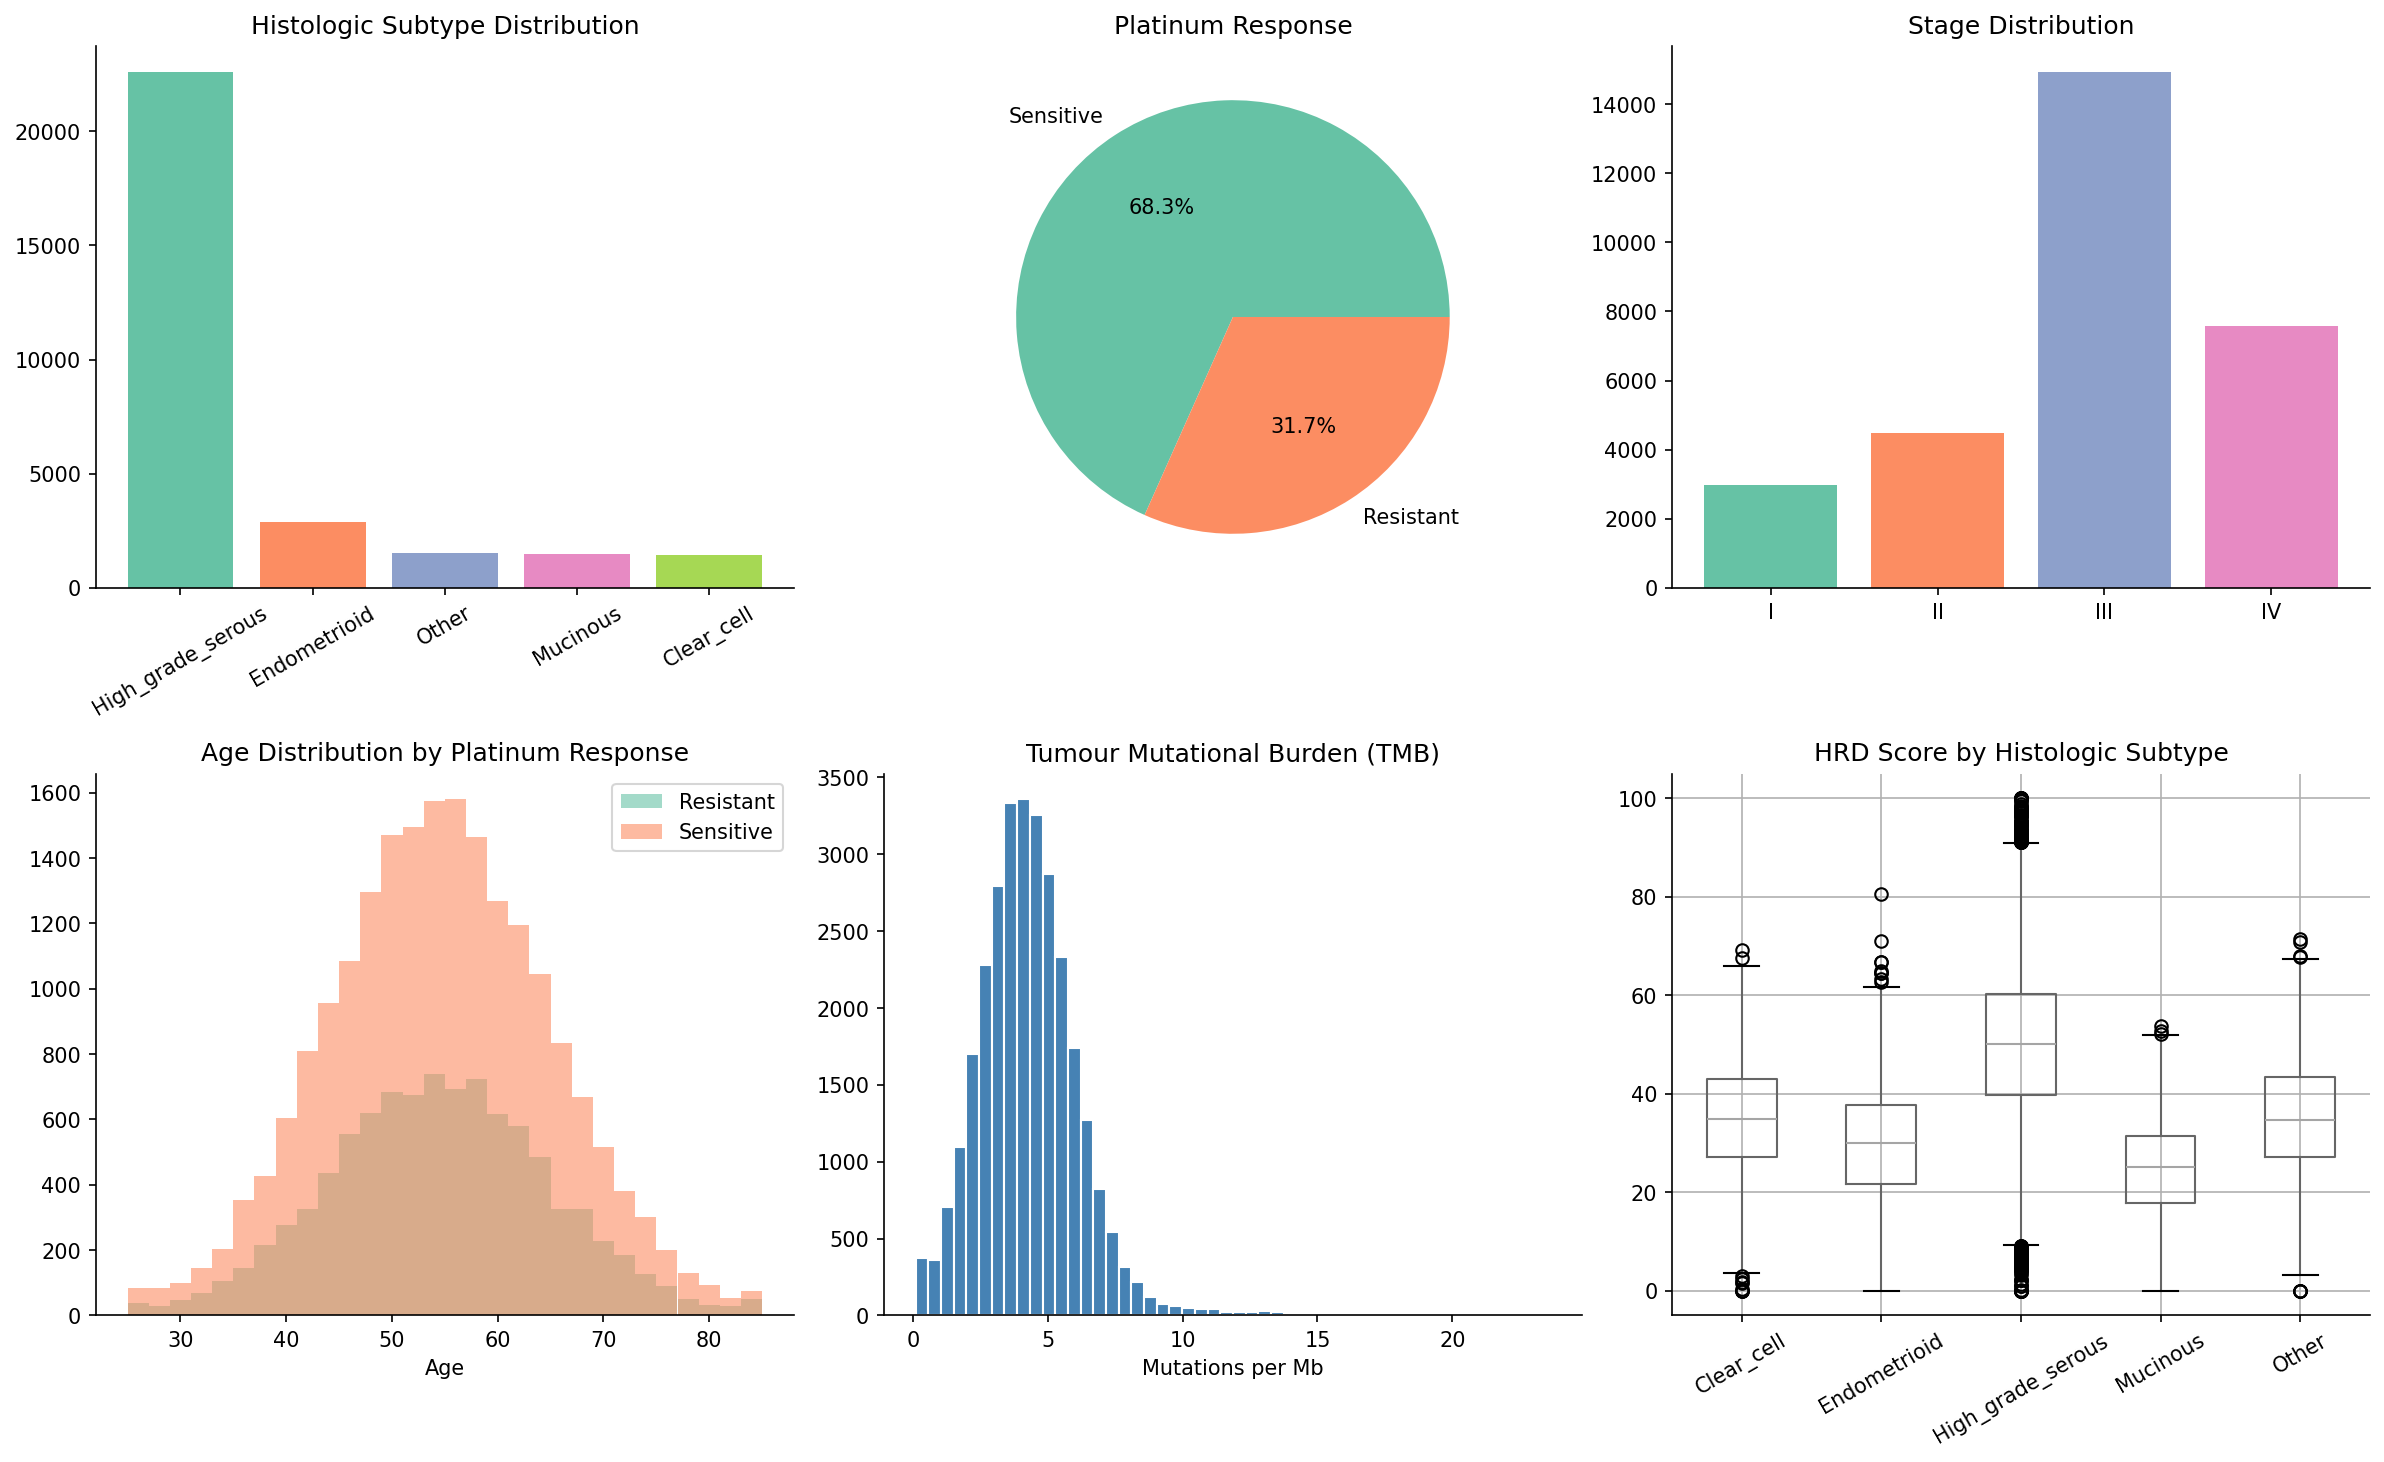

Figure saved: eda_overview.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Ovarian Cancer Cohort — Clinical & Genomic Overview', fontsize=14, fontweight='bold')

# 1. Histologic subtype distribution
subtype_counts = df['histologic_subtype'].value_counts()
axes[0,0].bar(subtype_counts.index, subtype_counts.values, color=sns.color_palette('Set2'))
axes[0,0].set_title('Histologic Subtype Distribution')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Platinum response
resp_counts = df['platinum_response'].value_counts()
axes[0,1].pie(resp_counts.values, labels=resp_counts.index, autopct='%1.1f%%',
              colors=sns.color_palette('Set2'))
axes[0,1].set_title('Platinum Response')

# 3. Stage distribution
stage_counts = df['stage'].value_counts().sort_index()
axes[0,2].bar(stage_counts.index, stage_counts.values, color=sns.color_palette('Set2'))
axes[0,2].set_title('Stage Distribution')

# 4. Age distribution by response
for response, grp in df.groupby('platinum_response'):
    axes[1,0].hist(grp['age'].dropna(), bins=30, alpha=0.6, label=response)
axes[1,0].set_title('Age Distribution by Platinum Response')
axes[1,0].set_xlabel('Age')
axes[1,0].legend()

# 5. TMB distribution
axes[1,1].hist(df['tmb_mut_per_mb'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[1,1].set_title('Tumour Mutational Burden (TMB)')
axes[1,1].set_xlabel('Mutations per Mb')

# 6. HRD score by subtype
df.boxplot(column='hrd_score', by='histologic_subtype', ax=axes[1,2])
axes[1,2].set_title('HRD Score by Histologic Subtype')
axes[1,2].set_xlabel('')
axes[1,2].tick_params(axis='x', rotation=30)
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: eda_overview.png')

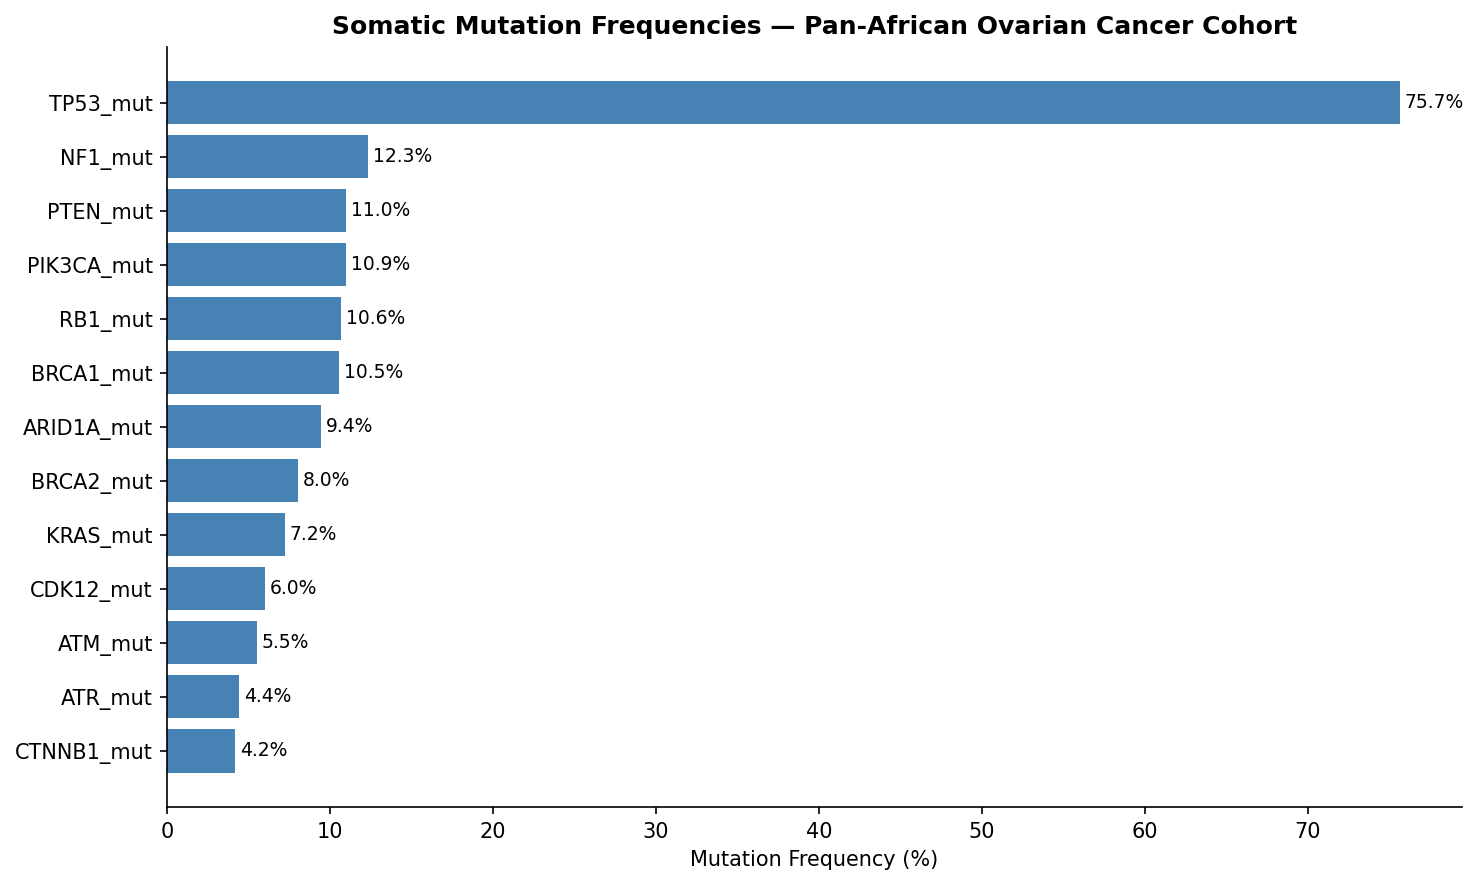

In [4]:
# Mutation frequency across cohort
mut_cols = ['TP53_mut','BRCA1_mut','BRCA2_mut','NF1_mut','RB1_mut',
            'PTEN_mut','PIK3CA_mut','KRAS_mut','ARID1A_mut','CTNNB1_mut',
            'CDK12_mut','ATM_mut','ATR_mut']

mut_freq = df[mut_cols].mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(mut_freq.index, mut_freq.values, color='steelblue')
ax.set_xlabel('Mutation Frequency (%)')
ax.set_title('Somatic Mutation Frequencies — Pan-African Ovarian Cancer Cohort', fontweight='bold')
for bar, val in zip(bars, mut_freq.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
#plt.savefig('mutation_frequencies.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Feature Engineering

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

df_ml = df.copy()

# ── Engineered features ─────────────────────────────────────────
# HRD-related: BRCA1 or BRCA2 mutated (homologous recombination deficiency)
df_ml['HRD_gene_mut'] = (df_ml['BRCA1_mut'] | df_ml['BRCA2_mut']).astype(int)

# Total driver mutation count
df_ml['total_driver_muts'] = df_ml[mut_cols].sum(axis=1)

# CNV burden categories
df_ml['high_cnv'] = (df_ml['cnv_burden_fraction_genome_altered'] > 0.3).astype(int)

# ── Encode categoricals ─────────────────────────────────────────
le = LabelEncoder()
df_ml['region_enc'] = le.fit_transform(df_ml['region'].fillna('Unknown'))
df_ml['subtype_enc'] = le.fit_transform(df_ml['histologic_subtype'].fillna('Unknown'))
df_ml['stage_enc'] = le.fit_transform(df_ml['stage'].fillna('Unknown'))
df_ml['msi_enc'] = le.fit_transform(df_ml['msi_status'].fillna('Unknown'))

# ── Define features & target ─────────────────────────────────────
feature_cols = (
    mut_cols +
    ['CCNE1_amp','MYC_amp','ERBB2_amp','PTEN_del','RB1_del','NF1_del'] +
    ['age','tmb_mut_per_mb','msi_score','cnv_burden_fraction_genome_altered',
     'aneuploidy_score','n_focal_amplifications','n_focal_deletions','hrd_score',
     'grade','HRD_gene_mut','total_driver_muts','high_cnv',
     'region_enc','subtype_enc','stage_enc','msi_enc']
)

# Target: platinum response (binary)
target = 'platinum_response'
df_ml[target] = (df_ml[target] == 'Sensitive').astype(int)

# Drop rows with missing values in features
df_clean = df_ml[feature_cols + [target]].dropna()
X = df_clean[feature_cols]
y = df_clean[target]

print(f'Features: {X.shape[1]}')
print(f'Samples: {X.shape[0]:,}')
print(f'Class balance: {y.value_counts(normalize=True).round(3).to_dict()}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Features: 35
Samples: 30,000
Class balance: {1: 0.683, 0: 0.317}

Train: 24,000 | Test: 6,000


## 4. ML Benchmark

We benchmark 5 models with cross-validation:
- **Logistic Regression** — interpretable baseline
- **Random Forest** — ensemble, handles non-linearity
- **XGBoost** — gradient boosting, often top performer
- **LightGBM** — fast gradient boosting
- **MLP** — neural network baseline

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (roc_auc_score, classification_report,
                              RocCurveDisplay, confusion_matrix)
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=6, random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42, eval_metric='logloss',
        verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        random_state=42, verbose=-1
    ),
    'MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64, 32),
            max_iter=500, random_state=42, early_stopping=True
        ))
    ])
}

# Cross-validation benchmark
results = {}
print('Running 5-fold cross-validation...\n')
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f'{name:25s} AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Running 5-fold cross-validation...

Logistic Regression       AUC: 0.5797 ± 0.0068
Random Forest             AUC: 0.5811 ± 0.0074
XGBoost                   AUC: 0.5709 ± 0.0068
LightGBM                  AUC: 0.5706 ± 0.0101
MLP                       AUC: 0.5681 ± 0.0111


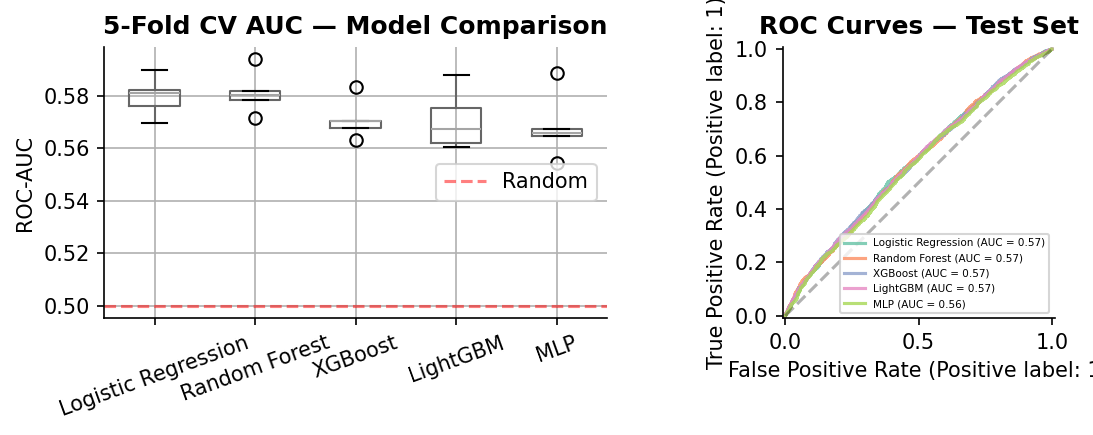

In [10]:
# Visualise benchmark results
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# CV scores boxplot
result_df = pd.DataFrame(results)
result_df.boxplot(ax=axes[0], rot=20)
axes[0].set_title('5-Fold CV AUC — Model Comparison', fontweight='bold')
axes[0].set_ylabel('ROC-AUC')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random')
axes[0].legend()

# ROC curves on test set
for name, model in models.items():
    model.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(model, X_test, y_test,
                                    name=name, ax=axes[1], alpha=0.8)
axes[1].set_title('ROC Curves — Test Set', fontweight='bold')
axes[1].plot([0,1],[0,1],'k--', alpha=0.3)
axes[1].legend(loc='lower right', fontsize=5)

plt.tight_layout()
#plt.savefig('ml_benchmark.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Evaluate prediction with confusion matrix

=== XGBoost — Test Set Performance ===
ROC-AUC: 0.5745

              precision    recall  f1-score   support

   Resistant       0.62      0.01      0.02      1901
   Sensitive       0.68      1.00      0.81      4099

    accuracy                           0.68      6000
   macro avg       0.65      0.50      0.41      6000
weighted avg       0.66      0.68      0.56      6000



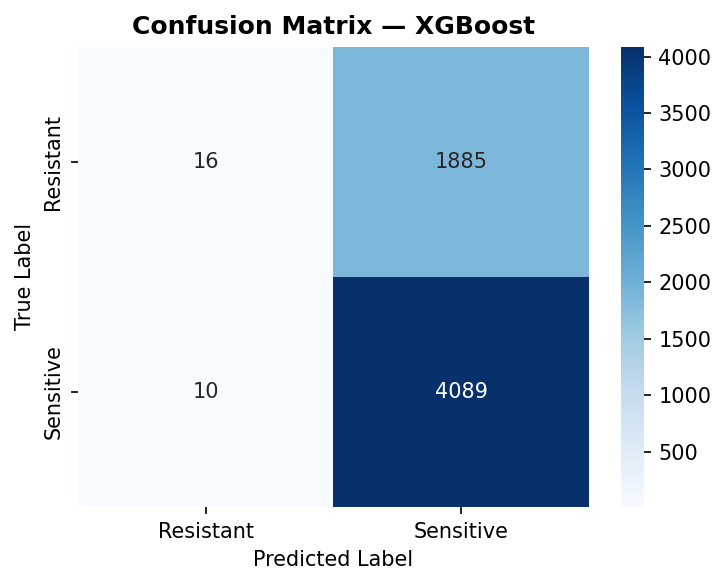

In [13]:
# best model training on full training set and test set evaluation
best_model = models['Logistic Regression']  # Replace with actual best model based on CV results
best_model.fit(X_train, y_train)

# Test set performance — best model
from sklearn.metrics import classification_report, confusion_matrix
import itertools

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print('=== XGBoost — Test Set Performance ===')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print(f'\n{classification_report(y_test, y_pred, target_names=["Resistant", "Sensitive"])}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Resistant','Sensitive'],
            yticklabels=['Resistant','Sensitive'], ax=ax)
ax.set_title('Confusion Matrix — XGBoost', fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Clinical Insights & Discussion

## ⚠️ Note on Model Performance

This notebook uses somatic mutation profiles to predict platinum chemotherapy 
response in ovarian cancer. Despite applying VAE for dimensionality reduction 
and multiple classifiers, AUC remains low (~0.56-0.58).

**Why this is expected:**
- Platinum resistance in ovarian cancer is driven by complex, multifactorial mechanisms 
  not captured by somatic mutations alone
- HGSOC cohorts are small — insufficient signal for robust ML generalisation
- Most resistance-associated mutations are private/rare, making generalisation difficult
- Published literature reports similar challenges — best models achieve AUC ~0.70 
  even with multi-omics integration

**Next step:** See `02_tcga_survival_prediction.ipynb` for a better-defined task 
using TCGA clinical + CNA data for overall survival prediction.

#--- done